v0_x = 1.6666666666666667
v0_y = 15.376641666666666
alpha = 1.462828312588189 радиан
alpha = 83.81388846354714 градусов


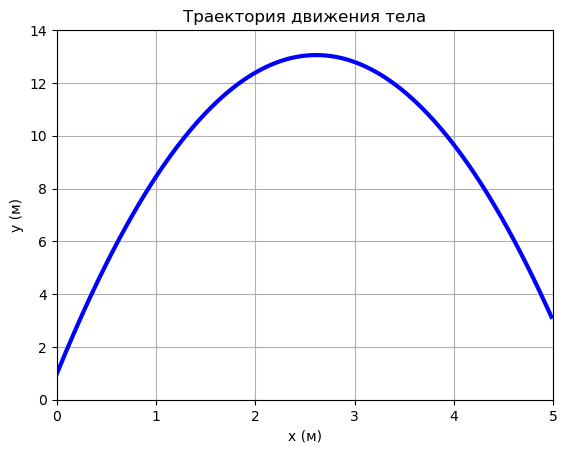

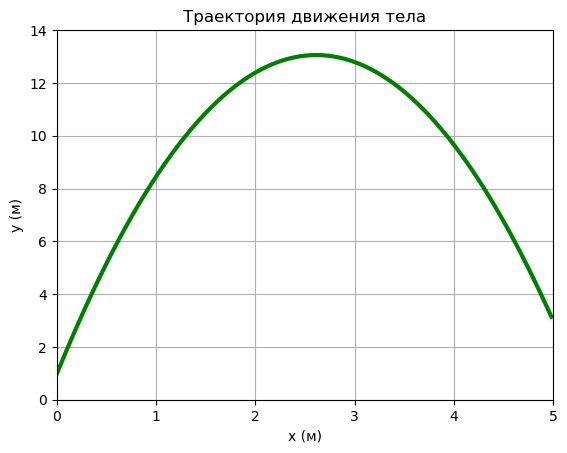

Точное время касания земли: 3.19970039267921 с
Приближенное время касания земли: 3.199699499540028 с
Относительная ошибка: 2.79132127978774e-5 %


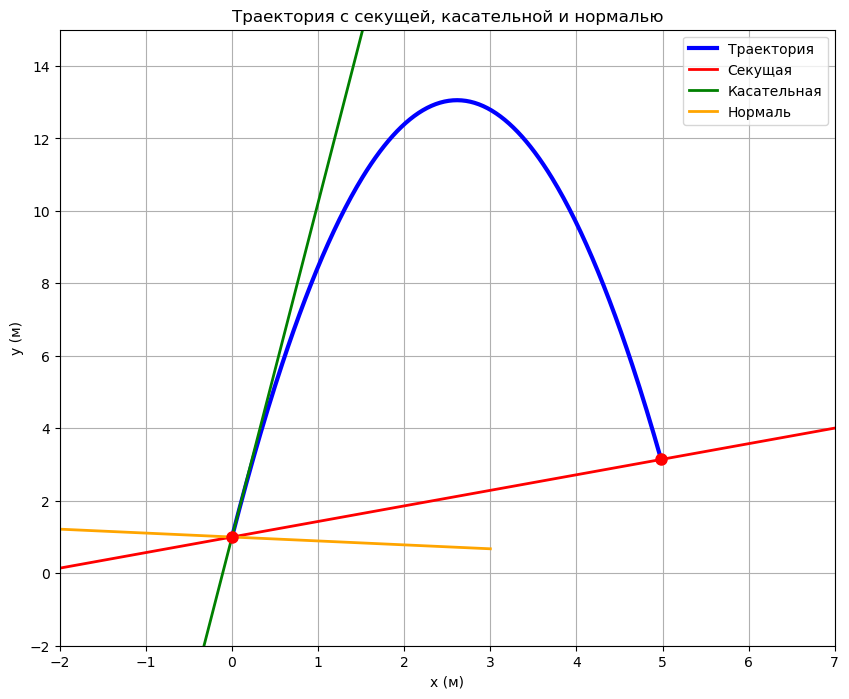

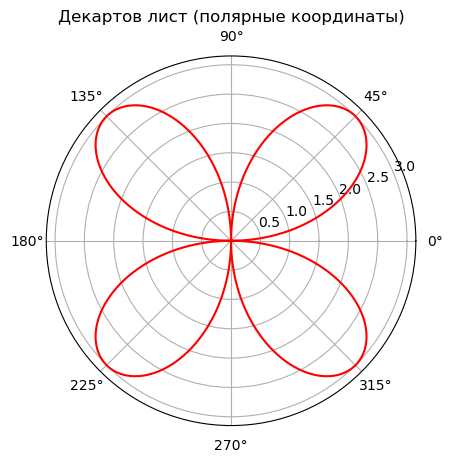

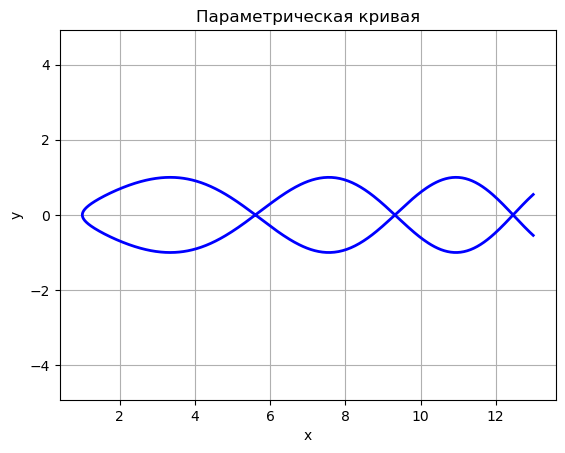

In [8]:
import math
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as const
import sympy

h_start = 1
h_end = 3.0
T = 3.0
s_end = 5.0

g = const.g

step = 0.01
t_list = [0 + i*step for i in range(int(T/step))]
t_array = np.arange(0, T, step)

v0_x = s_end / T
v0_y = (h_end - h_start + g/2 * T**2) / T

alpha = math.atan(v0_y / v0_x)
alpha_degrees = math.degrees(alpha)

print("v0_x =", v0_x)
print("v0_y =", v0_y)
print("alpha =", alpha, "радиан")
print("alpha =", alpha_degrees, "градусов")

s_x_list = [v0_x * t for t in t_list]
s_y_list = [h_start + v0_y * t - g * t**2 / 2 for t in t_list]

s_x_array = v0_x * t_array
s_y_array = h_start + v0_y * t_array - g * t_array**2 / 2

plt.figure()
plt.plot(s_x_list, s_y_list, 'b-', lw=3)
plt.title('Траектория движения тела')
plt.xlabel('x (м)')
plt.ylabel('y (м)')
plt.axis([0, s_end, 0, h_end + 11])
plt.grid(True)
plt.show()

plt.figure()
plt.plot(s_x_array, s_y_array, color='green', lw=3)
plt.title('Траектория движения тела')
plt.xlabel('x (м)')
plt.ylabel('y (м)')
plt.xlim(0, s_end)
plt.ylim(0, h_end + 11)
plt.grid(True)
plt.show()

t = sympy.symbols('t')
result = sympy.solve(h_start + v0_y * t - g * t**2 / 2, t)
t_star_exact = result[-1]
print("Точное время касания земли:", t_star_exact, "с")

t_stop = 4.0
t_search = np.arange(0, t_stop, step)
s_y_search = h_start + v0_y * t_search - g * t_search**2 / 2

k = 0
for i, value in enumerate(s_y_search[:-1]):
    if s_y_search[i] * s_y_search[i+1] < 0:
        k = i
        break

t1, t2 = t_search[k], t_search[k+1]
y1, y2 = s_y_search[k], s_y_search[k+1]

t_star_approx = t1 - y1 * (t2 - t1) / (y2 - y1)
print("Приближенное время касания земли:", t_star_approx, "с")

relative_error = abs(t_star_exact - t_star_approx) / t_star_exact * 100
print("Относительная ошибка:", relative_error, "%")

p_start = np.array([s_x_array[0], s_y_array[0]])
p_end = np.array([s_x_array[-1], s_y_array[-1]])

a_vector = p_end - p_start

p_line = np.array([p_start + a_vector * t for t in [-0.5, 1.5]])

vx = v0_x
vy = v0_y
k_tangent = vy / vx

x_tangent = np.array([-2, 3])
y_tangent = k_tangent * (x_tangent - p_start[0]) + p_start[1]

k_normal = -1 / k_tangent
y_normal = k_normal * (x_tangent - p_start[0]) + p_start[1]

plt.figure(figsize=(10, 8))
plt.plot(s_x_array, s_y_array, 'b-', lw=3, label='Траектория')
plt.plot(p_line[:, 0], p_line[:, 1], 'r-', lw=2, label='Секущая')
plt.plot(x_tangent, y_tangent, 'g-', lw=2, label='Касательная')
plt.plot(x_tangent, y_normal, 'orange', lw=2, label='Нормаль')
plt.plot(p_start[0], p_start[1], 'ro', markersize=8)
plt.plot(p_end[0], p_end[1], 'ro', markersize=8)
plt.title('Траектория с секущей, касательной и нормалью')
plt.xlabel('x (м)')
plt.ylabel('y (м)')
plt.axis([-2, s_end+2, -2, h_end+12])
plt.legend()
plt.grid(True)
plt.show()

a = 2
phi = np.linspace(0, 2*np.pi, 1000)
r = 3*a * np.sin(phi) * np.cos(phi) / (np.sin(phi)**2 + np.cos(phi)**2)

plt.figure()
ax = plt.subplot(111, projection='polar')
ax.plot(phi, np.abs(r), 'r-')
ax.set_title('Декартов лист (полярные координаты)')
plt.show()

t_param = np.linspace(-2, 2, 1000)
x = 3*t_param**2 + 1
y = np.sin(t_param**3 + t_param)

plt.figure()
plt.plot(x, y, 'b-', lw=2)
plt.title('Параметрическая кривая')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.axis('equal')
plt.show()